# HW #7 — Siamese Network for CIFAR-10 Object Verification
**Course:** Deep Learning for Computer Vision (EN525.733.8VL)  
**Due Date:** April 16, 2026  
**Samih Amer**

---

## Assignment Overview

In this assignment we build a **Siamese network** for **object verification** on the CIFAR-10 dataset. Unlike HW#5 (multi-class classification) the goal here is *not* to predict a single label for an input image — it is to decide **whether two images belong to the same class or not**. The network learns an *embedding space* in which pairs of images from the **same class (genuine pairs)** are pulled close together, and pairs from **different classes (imposter pairs)** are pushed apart beyond a fixed margin.

The two branches of the Siamese network are copies of a **VGG-16 convolutional backbone** (Simonyan & Zisserman, 2015) whose weights are **shared** between the branches. The last fully-connected layer produces a **4096-dimensional feature embedding** (the Softmax classification head is discarded). The Euclidean distance between the two embeddings feeds a **contrastive loss** (Chopra, Hadsell & LeCun, 2005) that enforces genuine/imposter separation.

### Tasks (from the assignment PDF)
1. Design a Siamese network using **VGG-16** as the two shared-weight branches.
2. Train on CIFAR-10 with **genuine and imposter pairs**, ensuring **each batch has an equal number of genuine and imposter pairs**.
3. Use the output of the last fully-connected layer as the **4096-d embedding** (no Softmax).
4. **Plot the learning curve** for training, validation, and test sets.
5. **Report per-class verification performance**.
6. Experiment with the margin parameter $m \in \{1.0,\, 1.5,\, 2.0\}$ in the contrastive loss.
7. Per the PDF note, we may **remove the last two pooling layers** of VGG-16 to control the size of the feature maps.

### Contrastive Loss Formulation

Let $G_W(\cdot)$ denote the shared embedding network and define the Euclidean distance between two embeddings as:
$$D_W(\mathbf{x}_i, \mathbf{x}_j) = \| G_W(\mathbf{x}_i) - G_W(\mathbf{x}_j) \|_2$$

For **genuine pairs** ($y = 0$, same class) we minimize the squared distance:
$$L_{\text{gen}}(D_W) = \tfrac{1}{2} \, D_W^{\,2}$$

For **imposter pairs** ($y = 1$, different classes) we use a hinge-style penalty that is zero once the distance exceeds the margin $m$:
$$L_{\text{imp}}(D_W) = \tfrac{1}{2} \, \max(0, \, m - D_W)^{\,2}$$

The total per-pair contrastive loss is:
$$L(W, y, \mathbf{x}_i, \mathbf{x}_j) = (1 - y)\, L_{\text{gen}}(D_W) + y\, L_{\text{imp}}(D_W)$$

### Network Architecture — VGG-16 Embedding Backbone (modified)

Standard VGG-16 has five convolutional blocks separated by max-pooling, followed by three fully-connected layers and a Softmax classifier. For this assignment:
- Input is **32x32x3 CIFAR-10** images.
- The **last two pooling layers (after blocks 4 and 5) are removed** — this preserves spatial resolution at 4x4 instead of shrinking to 1x1 (which would lose all spatial context on small CIFAR inputs).
- The Softmax head is **discarded**; we use the output of the last FC layer as the **4096-d embedding**.
- **Batch Normalization** is added after every conv layer (modern best practice; the original 2015 VGG paper did not use BN).
- The final 4096-d embedding is **L2-normalized onto the unit sphere** before the contrastive-loss distance step. This bounds $D_W \in [0, 2]$ and prevents embedding collapse — standard practice in verification-focused Siamese networks (FaceNet, SphereFace, ArcFace).

| Layer | Type | Filters / Units | Kernel | Output | Notes |
|---|---|---|---|---|---|
| Input | — | — | — | 32x32x3 | CIFAR-10 RGB |
| Conv 1-1 / 1-2 + Pool | Conv + BN + ReLU, MaxPool 2x2 | 64 | 3x3 | 16x16x64 | Block 1 |
| Conv 2-1 / 2-2 + Pool | Conv + BN + ReLU, MaxPool 2x2 | 128 | 3x3 | 8x8x128 | Block 2 |
| Conv 3-1 / 3-2 / 3-3 + Pool | Conv + BN + ReLU, MaxPool 2x2 | 256 | 3x3 | 4x4x256 | Block 3 |
| Conv 4-1 / 4-2 / 4-3 | Conv + BN + ReLU | 512 | 3x3 | 4x4x512 | **Pool removed** |
| Conv 5-1 / 5-2 / 5-3 | Conv + BN + ReLU | 512 | 3x3 | 4x4x512 | **Pool removed** |
| Flatten | — | 8192 | — | 8192 | 4x4x512 |
| FC 1 | Dense + ReLU + Dropout | 4096 | — | 4096 |  |
| FC 2 | Dense + ReLU + Dropout | 4096 | — | 4096 |  |
| FC 3 (Embedding) | Dense | 4096 | — | 4096 | **No Softmax** |

### Hyperparameters Summary

| Hyperparameter | Value | Rationale |
|---|---|---|
| **Optimizer** | Adam | Adaptive LR per parameter; reliable for deep Siamese CNNs |
| **Learning rate** | 1e-4 | Lower than classification default — pair gradients are noisier and VGG-16 is deep |
| **LR scheduler** | LinearLR warmup (1 epoch) + CosineAnnealingLR | Warmup lets BN stats settle before full LR; cosine decay afterwards |
| **Gradient clipping** | max_norm = 5.0 | Safety net against early-training gradient spikes |
| **Embedding normalization** | L2 (unit sphere) | Bounds $D_W \in [0, 2]$ and prevents embedding collapse — standard in FaceNet-style verification |
| **Batch size** | 128 (64 genuine + 64 imposter) | Equal genuine/imposter per batch (assignment requirement) |
| **Epochs per margin** | 25 | Extended run for sharper convergence; still <45 min total across 3 margin values on modern GPU |
| **Margin values** | 1.0, 1.5, 2.0 | As specified in the assignment |
| **Loss** | Contrastive (Chopra et al., 2005) | Siamese verification objective |
| **Backbone** | VGG-16 (last 2 pools removed) | As specified in the assignment |
| **Embedding dim** | 4096 | Output of last FC layer |
| **Weight init** | Kaiming (He) normal | Good default for ReLU-activated networks |
| **Regularization** | Dropout 0.5 on FC, BatchNorm on conv | Prevents overfitting in the wide FC head |
| **Data augmentation** | Random horizontal flip + random 32x32 crop with reflect pad | Standard CIFAR-10 augmentation |
| **Train/Val/Test split** | 45,000 / 5,000 / 10,000 | 5,000 stratified hold-out from CIFAR-10 train |
| **Pairs per epoch** | 40,000 train / 5,000 val / 10,000 test | Sampled with equal genuine/imposter |

### References
- Chopra, S., Hadsell, R. & LeCun, Y. *"Learning a Similarity Metric Discriminatively, with Application to Face Verification."* CVPR 2005.
- Hadsell, R., Chopra, S. & LeCun, Y. *"Dimensionality Reduction by Learning an Invariant Mapping."* CVPR 2006.
- Simonyan, K. & Zisserman, A. *"Very Deep Convolutional Networks for Large-Scale Image Recognition."* ICLR 2015 (VGG-16).
- Course Lecture 11 — *Siamese + Coupled Neural Networks*.

## 1. Imports and Setup

We use **PyTorch** for model definition and training. Key modules:
- `torch.nn` — defines conv, BN, FC layers for the VGG-16 backbone.
- `torch.nn.functional` — pairwise Euclidean distance, padding for augmentation.
- `torch.optim` — Adam optimizer and the cosine-annealing LR scheduler.
- `torch.utils.data` — custom `Dataset` classes for genuine/imposter pair generation.
- `sklearn.metrics` — ROC curve and AUC for verification evaluation.
- `matplotlib` / `seaborn` — all plotting.

GPU is used if available; the full experiment (3 margin values x 15 epochs) is on the order of ~1–2 hours on a modern consumer GPU.

In [ ]:
import os
import pickle
import time

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import roc_curve, auc

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

#  Reproducibility 
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

#  Device  
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 4070 Ti


## 2. Load CIFAR-10 Data

CIFAR-10 is stored as Python pickle files under `../HW 5/cifar-10-python/cifar-10-batches-py/` (reusing the dataset already downloaded for HW#5). Each training batch file contains a dict with:
- `data` — a `10000 x 3072` array of uint8 pixels (first 1024 = R, next 1024 = G, last 1024 = B).
- `labels` — 10,000 integer class labels in `[0, 9]`.

We load all **5 training batches (50,000 images)** and the **test batch (10,000 images)**, reshape to `(N, 3, 32, 32)`, scale pixel values to `[0, 1]` by dividing by 255, then apply **per-channel normalization** using the training-set mean and std. Zero-mean, unit-variance inputs help the optimizer converge faster and interact well with Batch Normalization.

In [ ]:
def unpickle(file):
    """Load a CIFAR-10 pickle batch file (returns the raw byte->numpy dict)."""
    with open(file, 'rb') as f:
        return pickle.load(f, encoding='bytes')


# CIFAR-10 lives under HW 5/cifar-10-python/ (shared between HWs to avoid duplicate download)
DATA_DIR = os.path.join("..", "HW 5", "cifar-10-python", "cifar-10-batches-py")

#   Load all 5 training batches and concatenate into one array  
train_images_list, train_labels_list = [], []
for i in range(1, 6):
    batch = unpickle(os.path.join(DATA_DIR, f"data_batch_{i}"))
    train_images_list.append(batch[b'data'])
    train_labels_list.extend(batch[b'labels'])
train_images_raw = np.concatenate(train_images_list, axis=0)     # (50000, 3072)
train_labels_raw = np.array(train_labels_list, dtype=np.int64)   # (50000,)

#   Load test batch (10,000 images)  
test_batch      = unpickle(os.path.join(DATA_DIR, "test_batch"))
test_images_raw = test_batch[b'data']
test_labels_raw = np.array(test_batch[b'labels'], dtype=np.int64)

#   Load human-readable class names for plot labels and per-class reports  
meta = unpickle(os.path.join(DATA_DIR, "batches.meta"))
class_names = [name.decode('utf-8') for name in meta[b'label_names']]

#   Reshape to (N, C, H, W) and scale to [0, 1]  
train_images = train_images_raw.reshape(-1, 3, 32, 32).astype(np.float32) / 255.0
test_images  = test_images_raw .reshape(-1, 3, 32, 32).astype(np.float32) / 255.0

#   Per-channel normalization using TRAINING set statistics  
# Centring + scaling each channel independently stabilizes gradients and BN.
channel_mean = train_images.mean(axis=(0, 2, 3))  # shape (3,)
channel_std  = train_images.std (axis=(0, 2, 3))
for c in range(3):
    train_images[:, c] = (train_images[:, c] - channel_mean[c]) / channel_std[c]
    test_images [:, c] = (test_images [:, c] - channel_mean[c]) / channel_std[c]

print(f"Channel means (R,G,B): {channel_mean}")
print(f"Channel stds  (R,G,B): {channel_std}")
print(f"Training set: {train_images.shape[0]:,} images, shape {train_images.shape[1:]}")
print(f"Test set:     {test_images.shape[0]:,} images")
print(f"Classes:      {class_names}")

Channel means (R,G,B): [0.4914009  0.48215896 0.4465308 ]
Channel stds  (R,G,B): [0.24703279 0.24348423 0.26158753]
Training set: 50,000 images, shape (3, 32, 32)
Test set:     10,000 images
Classes:      ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 3. Train / Validation / Test Split

The assignment requires learning curves for **training, validation, and test** sets. CIFAR-10 ships with 50,000 training + 10,000 test images and no official validation split. We therefore hold out **5,000 images** from the training set, **stratified by class** (500 per class, so class balance is preserved) to form the validation set. The remaining **45,000** training images are used for fitting the network.

| Split | Images | Purpose |
|---|---|---|
| Training | 45,000 | Fit the Siamese network weights |
| Validation | 5,000 | Monitor generalization across epochs; choose the distance threshold used for per-class verification |
| Test | 10,000 | Final held-out evaluation of verification performance |

In [3]:
VAL_PER_CLASS = 500  # stratified hold-out (500 per class -> 5,000 total)
rng = np.random.RandomState(SEED)

val_idx_list, train_idx_list = [], []
for c in range(10):
    # Indices of all training images of class c
    cls_idx = np.where(train_labels_raw == c)[0].copy()
    rng.shuffle(cls_idx)
    val_idx_list.append  (cls_idx[:VAL_PER_CLASS])
    train_idx_list.append(cls_idx[VAL_PER_CLASS:])

val_idx   = np.concatenate(val_idx_list)
train_idx = np.concatenate(train_idx_list)

# Final tensors for each split
X_train = train_images     [train_idx]
y_train = train_labels_raw [train_idx]
X_val   = train_images     [val_idx]
y_val   = train_labels_raw [val_idx]
X_test  = test_images
y_test  = test_labels_raw

print(f"Training:    {X_train.shape[0]:,} images")
print(f"Validation:  {X_val.shape[0]:,} images")
print(f"Test:        {X_test.shape[0]:,} images")
# Per-class counts sanity check (should be exactly 4500 / 500 / 1000 per class)
print("\nPer-class sample counts:")
for c in range(10):
    print(f"  {class_names[c]:>11}: "
          f"train={np.sum(y_train == c):>5}, "
          f"val={np.sum(y_val == c):>4}, "
          f"test={np.sum(y_test == c):>4}")

Training:    45,000 images
Validation:  5,000 images
Test:        10,000 images

Per-class sample counts:
     airplane: train= 4500, val= 500, test=1000
   automobile: train= 4500, val= 500, test=1000
         bird: train= 4500, val= 500, test=1000
          cat: train= 4500, val= 500, test=1000
         deer: train= 4500, val= 500, test=1000
          dog: train= 4500, val= 500, test=1000
         frog: train= 4500, val= 500, test=1000
        horse: train= 4500, val= 500, test=1000
         ship: train= 4500, val= 500, test=1000
        truck: train= 4500, val= 500, test=1000


## 4. Genuine / Imposter Pair Datasets

Training a Siamese network requires **pairs**, not individual images:
- **Genuine pairs** (label $y = 0$): two different images from the **same** class.
- **Imposter pairs** (label $y = 1$): two images from **different** classes.

The assignment explicitly requires that **each mini-batch contains an equal number of genuine and imposter pairs**. We achieve this with a custom `Dataset` whose `__getitem__(idx)` returns a genuine pair when `idx` is even and an imposter pair when `idx` is odd. Combined with `DataLoader(shuffle=False)` and `batch_size = 128`, each batch is then guaranteed to contain exactly **64 genuine + 64 imposter** pairs.

Two dataset variants are defined below:
- **`DynamicSiamesePairDataset`** — generates a *fresh random* pair on every `__getitem__` call. Used for **training** so the network sees new pair combinations each epoch, which greatly expands the effective training set beyond what a fixed pair list would provide.
- **`FixedSiamesePairDataset`** — generates a deterministic list of pairs at construction time (seeded). Used for **validation and test** so that metrics are comparable across epochs and across different margin values.

The training dataset also supports **data augmentation** (random horizontal flip + random 32x32 crop with 4-pixel reflect padding), applied **independently** to each image of a pair. Augmentation is disabled for validation/test so that the only source of variation there is the network itself.

In [ ]:
class DynamicSiamesePairDataset(Dataset):
    """Generates genuine / imposter pairs on-the-fly for training.

    Design:
      idx % 2 == 0  ->  genuine (same-class) pair
      idx % 2 == 1  ->  imposter (different-class) pair

    Used with DataLoader(shuffle=False) so each batch has a fixed 50/50 split.
    Pair contents are drawn freshly every call via NumPy's global RNG, so each
    epoch the network sees different pair combinations (an important source of
    diversity given the huge combinatorial space of possible pairs).
    """

    def __init__(self, images, labels, num_pairs, augment=False):
        # Store images as a torch tensor so __getitem__ only pays a .clone() cost
        self.images   = torch.from_numpy(images)
        self.labels   = labels
        self.num_pairs = num_pairs
        self.augment  = augment
        # Per-class index arrays precomputed once for O(1) random sampling
        self.class_to_idx = {c: np.where(labels == c)[0] for c in range(10)}

    def __len__(self):
        return self.num_pairs

    def __getitem__(self, idx):
        # Balanced batch construction: alternating genuine / imposter
        y = idx % 2  # 0 = genuine, 1 = imposter

        # Pick a random anchor class
        c1 = np.random.randint(0, 10)

        if y == 0:
            # Genuine: two distinct images from the same class c1
            i, j = np.random.choice(self.class_to_idx[c1], size=2, replace=False)
            c2 = c1
        else:
            # Imposter: one image from c1, one from a different class c2
            c2 = np.random.choice([c for c in range(10) if c != c1])
            i  = np.random.choice(self.class_to_idx[c1])
            j  = np.random.choice(self.class_to_idx[c2])

        img1 = self.images[i].clone()  # clone so we do not mutate the cache
        img2 = self.images[j].clone()

        if self.augment:
            img1 = self._augment(img1)
            img2 = self._augment(img2)

        # Return also the two class ids so downstream metrics can do per-class analysis
        return img1, img2, torch.tensor(float(y)), int(c1), int(c2)

    @staticmethod
    def _augment(img):
        """Random horizontal flip + random 32x32 crop with 4-px reflect padding."""
        # Horizontal flip with probability 0.5 (CIFAR objects are mirror-symmetric-ish)
        if torch.rand(1).item() > 0.5:
            img = torch.flip(img, dims=[2])
        # Pad 4 pixels each side -> (3, 40, 40), then take a random 32x32 crop
        img = F.pad(img, (4, 4, 4, 4), mode='reflect')
        i = torch.randint(0, 8, (1,)).item()
        j = torch.randint(0, 8, (1,)).item()
        return img[:, i:i + 32, j:j + 32]


class FixedSiamesePairDataset(Dataset):
    """Pre-generates a deterministic list of (genuine + imposter) pairs.

    Used for validation / test so that metrics are reproducible across epochs
    and across margin values. The first num_pairs/2 samples are genuine;
    the remaining num_pairs/2 are imposter. With DataLoader(shuffle=False,
    batch_size even) each batch still naturally contains pairs from both halves
    on average; batch composition does not matter at eval time because BN
    uses running statistics.
    """

    def __init__(self, images, labels, num_pairs, seed=123):
        assert num_pairs % 2 == 0, "num_pairs must be even (equal genuine/imposter)"
        self.images = torch.from_numpy(images)
        self.labels = labels
        self.pairs  = []  # list of (i, j, y, c_i, c_j)

        rng = np.random.RandomState(seed)
        class_to_idx = {c: np.where(labels == c)[0] for c in range(10)}
        n_half = num_pairs // 2

        #   Genuine pairs (y = 0): two distinct images from same class  
        for _ in range(n_half):
            c   = rng.randint(0, 10)
            i, j = rng.choice(class_to_idx[c], size=2, replace=False)
            self.pairs.append((int(i), int(j), 0, int(c), int(c)))

        #   Imposter pairs (y = 1): one image from each of two different classes  
        for _ in range(n_half):
            c1 = rng.randint(0, 10)
            c2 = rng.choice([c for c in range(10) if c != c1])
            i  = rng.choice(class_to_idx[c1])
            j  = rng.choice(class_to_idx[c2])
            self.pairs.append((int(i), int(j), 1, int(c1), int(c2)))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        i, j, y, ci, cj = self.pairs[idx]
        return self.images[i], self.images[j], torch.tensor(float(y)), ci, cj


#   Hyperparameter constants for data loading  
BATCH_SIZE             = 128     # Must be even (64 genuine + 64 imposter per batch)
TRAIN_PAIRS_PER_EPOCH  = 40000   # ~ 1 pair per training image per epoch
VAL_PAIRS              = 5000    # Even split: 2500 genuine + 2500 imposter
TEST_PAIRS             = 10000   # Even split: 5000 genuine + 5000 imposter

#   Instantiate the three datasets  
train_dataset = DynamicSiamesePairDataset(X_train, y_train, TRAIN_PAIRS_PER_EPOCH, augment=True)
val_dataset   = FixedSiamesePairDataset  (X_val,   y_val,   VAL_PAIRS,  seed=123)
test_dataset  = FixedSiamesePairDataset  (X_test,  y_test,  TEST_PAIRS, seed=456)

#   DataLoaders  
# shuffle=False preserves the even/odd -> genuine/imposter pattern within each batch.
# num_workers=0 avoids RNG-per-worker issues with the dynamic dataset.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=(device.type == "cuda"))
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=(device.type == "cuda"))
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=(device.type == "cuda"))

print(f"Training:   {len(train_dataset):,} pairs ({len(train_loader)} batches/epoch)")
print(f"Validation: {len(val_dataset):,} pairs ({len(val_loader)} batches)")
print(f"Test:       {len(test_dataset):,} pairs ({len(test_loader)} batches)")

Training:   40,000 pairs (313 batches/epoch)
Validation: 5,000 pairs (40 batches)
Test:       10,000 pairs (79 batches)


### Sanity Check — Visualize Sample Pairs

Before training, we display two **genuine** and two **imposter** pairs drawn from the training dataset. Each row shows one pair; the pair type (genuine vs. imposter) and class names are written next to the images so we can visually confirm that pair-generation is correct.

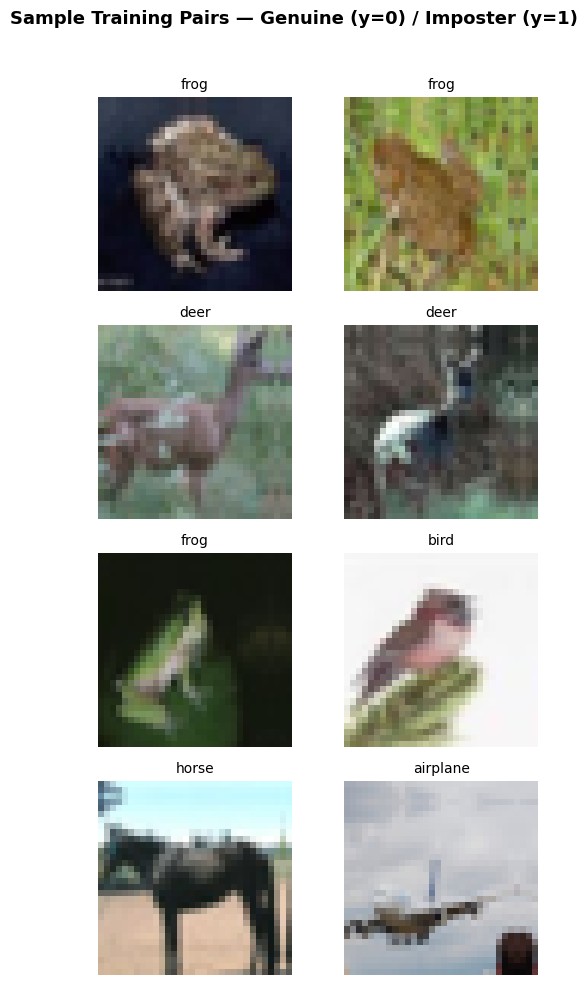

In [5]:
def denormalize(img_tensor):
    """Reverse per-channel normalization so we can show the image as RGB in [0, 1]."""
    img = img_tensor.clone().numpy()
    for c in range(3):
        img[c] = img[c] * channel_std[c] + channel_mean[c]
    return np.clip(img.transpose(1, 2, 0), 0, 1)


fig, axes = plt.subplots(4, 2, figsize=(6, 10))
fig.suptitle("Sample Training Pairs — Genuine (y=0) / Imposter (y=1)",
             fontsize=13, fontweight='bold')

# Grab 2 genuine pairs (even idx) and 2 imposter pairs (odd idx)
sample_indices = [0, 2, 1, 3]  # even, even, odd, odd
for row, idx in enumerate(sample_indices):
    img1, img2, y, c1, c2 = train_dataset[idx]
    pair_type = "Genuine (y=0)" if int(y.item()) == 0 else "Imposter (y=1)"

    axes[row, 0].imshow(denormalize(img1))
    axes[row, 0].set_title(f"{class_names[c1]}", fontsize=10)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(denormalize(img2))
    axes[row, 1].set_title(f"{class_names[c2]}", fontsize=10)
    axes[row, 1].axis('off')

    # Row label on the left
    axes[row, 0].set_ylabel(pair_type, fontsize=11, fontweight='bold',
                            rotation=0, labelpad=55, va='center')

plt.tight_layout(rect=[0.08, 0, 1, 0.96])
plt.show()

## 5. VGG-16 Embedding Backbone

Our backbone follows the classic **VGG-16** architecture (Simonyan & Zisserman, 2015), modified for 32x32 CIFAR-10 input and Siamese verification:

1. **5 convolutional blocks**, each composed of 2-3 conv layers with 3x3 kernels, stride 1, and "same" (padding = 1) spatial size. Every conv is followed by **BatchNorm** and **ReLU**.
2. **Max-pooling (2x2, stride 2)** after blocks 1, 2, and 3 only. **The pools that would normally come after blocks 4 and 5 are removed** (as allowed by the assignment) -- this keeps the feature map at 4x4 x 512 rather than shrinking it to 1x1 x 512, which would destroy all remaining spatial context on these small 32x32 inputs.
3. **3 fully-connected layers** with ReLU and Dropout (0.5) between them. The final FC output is the **4096-dimensional embedding vector**. **No Softmax** is applied; embeddings are consumed directly by the contrastive loss.
4. **Batch Normalization** after every conv layer. The original 2015 VGG paper predates BN, but it is a standard improvement that stabilizes training of this very deep network on small inputs and permits higher learning rates.
5. **L2 normalization of the 4096-d embedding.** The last step of `forward()` is `F.normalize(embedding, p=2, dim=1)`, which projects each embedding onto the unit sphere so that $\|G_W(\mathbf{x})\|_2 = 1$. This:
    - **Bounds the pairwise distance** $D_W \in [0, 2]$ for all inputs (two antipodal unit vectors give $D = 2$), so loss magnitudes stay predictable across training.
    - **Prevents embedding collapse** -- the classic Siamese failure mode where an unnormalized network learns to output the *same* (near-zero) vector for every input, trivially minimising the genuine loss and saturating the imposter hinge. L2 normalization removes the one degree of freedom (overall scale) that the optimiser would otherwise exploit.
    - Is **standard practice** in verification-focused Siamese and metric-learning networks (FaceNet, SphereFace, ArcFace, CosFace, etc.).

### Spatial Dimension Flow
```
Input              32 x 32 x   3
Block 1 + Pool     16 x 16 x  64
Block 2 + Pool      8 x  8 x 128
Block 3 + Pool      4 x  4 x 256
Block 4 (no pool)   4 x  4 x 512
Block 5 (no pool)   4 x  4 x 512
Flatten                 8192
FC1                     4096
FC2                     4096
FC3                     4096    <-- raw 4096-d embedding
L2 norm                 4096    <-- unit-norm 4096-d embedding
```

In [ ]:
class VGG16Embedding(nn.Module):
    """VGG-16 backbone modified for CIFAR-10 (32x32) Siamese embedding.

    Architecture (per the assignment diagram + last 2 pools removed):
        Block 1: Conv(3->64)   + Conv(64->64)     + Pool    -> 16x16x64
        Block 2: Conv(64->128) + Conv(128->128)   + Pool    -> 8x8x128
        Block 3: Conv(128->256)+ Conv(256->256)x2 + Pool    -> 4x4x256
        Block 4: Conv(256->512)+ Conv(512->512)x2          -> 4x4x512  (NO pool)
        Block 5: Conv(512->512)x3                          -> 4x4x512  (NO pool)
        Flatten 4*4*512 = 8192
        FC(8192 -> 4096) + ReLU + Dropout(0.5)
        FC(4096 -> 4096) + ReLU + Dropout(0.5)
        FC(4096 -> 4096)                                   -> raw 4096-d embedding
        L2 normalize                                        -> unit-norm 4096-d embedding

    Modifications vs. original 2015 VGG-16:
      - Last two max-pooling layers removed (assignment hint) to keep 4x4 feature maps
      - Softmax classification head removed (we train with contrastive loss on embeddings)
      - BatchNorm added after every conv (modern best practice)
      - Final 4096-d embedding is L2-normalized to the unit sphere.  This bounds the
        pairwise distance in [0, 2] and prevents embedding collapse -- a failure mode
        where the net learns to output the same (near-zero) vector for every input
        to trivially minimize the genuine-pair loss.  Standard practice in face-
        verification networks (FaceNet, SphereFace, ArcFace, etc.).
    """

    EMBEDDING_DIM = 4096

    def __init__(self):
        super().__init__()

        # Small helper: a conv -> BN -> ReLU block (used everywhere in VGG)
        def conv_bn_relu(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
            )

        #   Block 1 (2 convs + pool):  3 -> 64 -> 64,  32x32 -> 16x16  
        self.block1 = nn.Sequential(
            conv_bn_relu(3,  64),    # Conv 1-1
            conv_bn_relu(64, 64),    # Conv 1-2
            nn.MaxPool2d(2, 2),
        )
        #  Block 2 (2 convs + pool):  64 -> 128 -> 128,  16x16 -> 8x8 
        self.block2 = nn.Sequential(
            conv_bn_relu( 64, 128),  # Conv 2-1
            conv_bn_relu(128, 128),  # Conv 2-2
            nn.MaxPool2d(2, 2),
        )
        #  Block 3 (3 convs + pool):  128 -> 256 -> 256 -> 256,  8x8 -> 4x4 
        self.block3 = nn.Sequential(
            conv_bn_relu(128, 256),  # Conv 3-1
            conv_bn_relu(256, 256),  # Conv 3-2
            conv_bn_relu(256, 256),  # Conv 3-3
            nn.MaxPool2d(2, 2),
        )
        #  Block 4 (3 convs, POOL REMOVED):  256 -> 512 -> 512 -> 512,  stays 4x4 
        self.block4 = nn.Sequential(
            conv_bn_relu(256, 512),  # Conv 4-1
            conv_bn_relu(512, 512),  # Conv 4-2
            conv_bn_relu(512, 512),  # Conv 4-3
        )
        # Block 5 (3 convs, POOL REMOVED):  512 -> 512 -> 512 -> 512,  stays 4x4 
        self.block5 = nn.Sequential(
            conv_bn_relu(512, 512),  # Conv 5-1
            conv_bn_relu(512, 512),  # Conv 5-2
            conv_bn_relu(512, 512),  # Conv 5-3
        )

        # Fully-connected head (three Dense layers; no Softmax) 
        self.classifier = nn.Sequential(
            nn.Linear(4 * 4 * 512, 4096),   # FC 1
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),           # FC 2
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, self.EMBEDDING_DIM),  # FC 3 -- final 4096-d embedding
        )

        # Kaiming normal init is the standard for ReLU-activated conv/FC layers
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_ (m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = x.flatten(1)              # (B, 8192)
        x = self.classifier(x)        # (B, 4096) -- raw 4096-d embedding
        # L2-normalize to the unit sphere:  ||e||_2 = 1.  This bounds pairwise
        # distances in [0, 2] and prevents embedding collapse under contrastive loss.
        return F.normalize(x, p=2, dim=1)


# Quick sanity check: forward shape, parameter count, and unit-norm confirmation
_test_bb   = VGG16Embedding()
_n_params  = sum(p.numel() for p in _test_bb.parameters())
_dummy_in  = torch.randn(2, 3, 32, 32)
_dummy_out = _test_bb(_dummy_in)
_norms     = _dummy_out.norm(dim=1).detach().numpy()
print(f"VGG-16 embedding backbone parameters: {_n_params:,}")
print(f"Input  shape: {tuple(_dummy_in.shape)}  ->  Embedding shape: {tuple(_dummy_out.shape)}")
print(f"Embedding norms (should be ~1.0 after L2 normalize): {_norms}")
del _test_bb, _dummy_in, _dummy_out, _norms


VGG-16 embedding backbone parameters: 81,844,288
Input  shape: (2, 3, 32, 32)  ->  Embedding shape: (2, 4096)
Embedding norms (should be ~1.0 after L2 normalize): [1. 1.]


### Siamese Wrapper (Weight Sharing)

The defining property of a Siamese network is that its two branches **share weights**. In PyTorch this is achieved most cleanly by having a **single backbone module that is called twice** per forward pass — once per image of the pair. Because both calls go through the *same* `nn.Parameter` tensors, there is no need to duplicate the backbone or explicitly tie weights: gradients from both branches accumulate naturally on the shared parameters during `.backward()`.

In [7]:
class SiameseNet(nn.Module):
    """Siamese network with weight sharing.

    The two 'branches' are both calls to the same VGG16Embedding module.
    Gradients from both images combine on the shared weights automatically.
    """

    def __init__(self):
        super().__init__()
        self.backbone = VGG16Embedding()

    def forward_one(self, x):
        """Embed a single batch of images (useful for inference / visualization)."""
        return self.backbone(x)

    def forward(self, x1, x2):
        """Return the two embeddings for a pair batch."""
        e1 = self.backbone(x1)
        e2 = self.backbone(x2)
        return e1, e2

## 6. Contrastive Loss

The contrastive loss (Chopra, Hadsell & LeCun, 2005) drives **genuine pairs close together** and **imposter pairs apart by at least a margin $m$** in embedding space:

$$L_{\text{gen}}(D_W) = \tfrac{1}{2}\, D_W^{\,2} \qquad\qquad L_{\text{imp}}(D_W) = \tfrac{1}{2}\, \max(0,\, m - D_W)^{\,2}$$

$$L(y, D_W) = (1 - y)\, L_{\text{gen}}(D_W) \;+\; y\, L_{\text{imp}}(D_W)$$

where $D_W(\mathbf{x}_i, \mathbf{x}_j) = \|G_W(\mathbf{x}_i) - G_W(\mathbf{x}_j)\|_2$ is the Euclidean distance between the two embeddings, and $y = 0$ for genuine / $y = 1$ for imposter.

**Intuition for each term:**
- **Genuine ($y=0$):** $(1 - y) = 1$, so we minimize $\tfrac{1}{2} D_W^2$ — shrinking the embedding distance toward zero. This term is a quadratic bowl; the gradient always points “inward.”
- **Imposter ($y=1$):** $y = 1$, so we minimize $\tfrac{1}{2}\max(0, m - D_W)^2$. This is a **hinge** penalty: if $D_W \ge m$ the loss is 0 (no gradient — the pair is already well-separated, saving capacity for harder pairs); if $D_W < m$ we push the two images further apart until they exceed the margin.
- **The margin $m$** thus controls **how far apart** imposter pairs must be. Larger $m$ enforces stronger separation but makes training harder (more pairs inside the hinge region, more competing gradient pull on the shared backbone). We experiment with $m \in \{1.0,\, 1.5,\, 2.0\}$ per the assignment.

In [8]:
class ContrastiveLoss(nn.Module):
    """Contrastive loss (Chopra, Hadsell & LeCun, 2005).

        L = (1 - y) * 0.5 * D^2   +   y * 0.5 * max(0, m - D)^2

    where y = 0 for genuine pairs, y = 1 for imposter pairs, and D is the
    Euclidean distance between the two embeddings produced by the shared
    backbone.
    """

    def __init__(self, margin: float = 1.0):
        super().__init__()
        self.margin = margin

    def forward(self, e1: torch.Tensor, e2: torch.Tensor, y: torch.Tensor):
        # Pairwise Euclidean distance; eps inside sqrt prevents a NaN gradient at D=0
        D = F.pairwise_distance(e1, e2, p=2, eps=1e-6)

        # Genuine component: pulls same-class pairs together quadratically
        L_gen = 0.5 * D.pow(2)
        # Imposter component: hinge penalty active only when D < margin
        L_imp = 0.5 * torch.clamp(self.margin - D, min=0.0).pow(2)

        # Pair-level loss (only one term is non-zero per pair, selected by y)
        loss_per_pair = (1.0 - y) * L_gen + y * L_imp

        # Return the mean loss (for optimization) and the raw distances (for metrics)
        return loss_per_pair.mean(), D

## 7. Training and Evaluation Functions

### Training step
For each batch of (img1, img2, y) pairs we:
1. Forward both images through the **shared backbone** to get the two L2-normalized embeddings $e_1, e_2$ (so $\|e_1\| = \|e_2\| = 1$).
2. Compute the **contrastive loss** and collect the per-pair distances $D \in [0, 2]$.
3. `loss.backward()`, then **gradient clipping** at `max_norm = 5.0`, then `optimizer.step()`.  Clipping is a safety net against occasional early-training gradient spikes.
4. Track running loss, the mean distance of genuine pairs, and the mean distance of imposter pairs.  During successful training these two numbers should **diverge** -- genuine distances shrink toward 0 while imposter distances grow toward (or past) the margin.

### Evaluation step
On val / test we collect, for **every pair**:
- the distance $D$
- the true label $y$ (genuine/imposter)
- the class ids of both images $c_1, c_2$ (used later for **per-class verification accuracy**)

From these tensors we compute:
- **Loss** -- the same contrastive loss formula for the learning curve.
- **Verification accuracy at the optimal threshold** -- sweep the distance threshold $\tau$ and pick the $\tau$ that maximizes $(TP + TN)/N$.  The threshold is always selected on validation data, then applied to test.
- **EER** and **ROC AUC** via `sklearn.metrics.roc_curve`.

### Optimizer and LR schedule
- **Adam** with base learning rate $10^{-4}$.  Contrastive-loss gradients are noisier than classification gradients (each update touches two images), and VGG-16 is deep enough that the usual $10^{-3}$ would be aggressive.  $10^{-4}$ is a good balance.
- **Linear warmup for 1 epoch** (LR climbs from $10^{-6}$ to $10^{-4}$).  A cold-started VGG-16 with 4096-d embeddings can produce large gradients in the very first batches; warmup lets the BatchNorm running statistics settle and the weights move into a well-behaved regime before we apply the full LR.
- **CosineAnnealingLR** for the remaining 24 epochs -- smoothly decays the LR to zero so the network settles into a fine-grained minimum.
- **Gradient clipping** at `max_norm = 5.0`.  Belt-and-suspenders with the L2-normalized embeddings and LR warmup -- together they make training robust against the embedding-collapse failure mode seen with an earlier un-normalized version of this notebook.

In [ ]:
def evaluate_siamese(model, loader, criterion):
    """Run the model over a pair DataLoader and collect per-pair statistics.

    Returns a dict with:
      - loss:     mean contrastive loss over all pairs
      - D:        np.ndarray of per-pair Euclidean distances
      - y:        np.ndarray of per-pair labels (0=genuine, 1=imposter)
      - c1, c2:   np.ndarrays of class ids for the two images in each pair
    """
    model.eval()
    all_D, all_y, all_c1, all_c2 = [], [], [], []
    total_loss = 0.0
    total_pairs = 0

    with torch.no_grad():
        for img1, img2, y, c1, c2 in loader:
            img1 = img1.to(device, non_blocking=True)
            img2 = img2.to(device, non_blocking=True)
            y    = y   .to(device, non_blocking=True)

            e1, e2 = model(img1, img2)
            loss, D = criterion(e1, e2, y)

            total_loss  += loss.item() * img1.size(0)
            total_pairs += img1.size(0)

            all_D .append(D .cpu().numpy())
            all_y .append(y .cpu().numpy())
            all_c1.append(np.asarray(c1))
            all_c2.append(np.asarray(c2))

    return {
        'loss': total_loss / total_pairs,
        'D':    np.concatenate(all_D),
        'y':    np.concatenate(all_y),
        'c1':   np.concatenate(all_c1),
        'c2':   np.concatenate(all_c2),
    }


def find_best_threshold(distances, labels):
    """Sweep distance thresholds and pick the one that maximises verification accuracy.

    Decision rule:  D < tau  -> predict genuine (y=0);  D >= tau -> predict imposter (y=1).
    Accuracy = (TP + TN) / N.
    """
    thresholds = np.linspace(distances.min(), distances.max(), 500)
    best_acc, best_tau = 0.0, thresholds[0]
    for tau in thresholds:
        pred = (distances >= tau).astype(np.int64)   # 1=imposter, 0=genuine
        acc  = np.mean(pred == labels.astype(np.int64))
        if acc > best_acc:
            best_acc, best_tau = acc, tau
    return float(best_tau), float(best_acc)


#   Training safety constants (tuned to prevent embedding collapse)  
GRAD_CLIP_MAX_NORM = 5.0   # Gradient-norm clip threshold (safety against occasional spikes)
WARMUP_EPOCHS      = 1     # Linear LR warmup for first N epoch(s):  0.01x -> 1x of base LR


def train_siamese(model, criterion, num_epochs, lr=1e-4, tag=""):
    """Train the Siamese network for num_epochs, tracking per-epoch train/val/test metrics.

    LR schedule:  linear warmup for WARMUP_EPOCHS epoch(s), then cosine anneal.
    Gradient clipping at max_norm = GRAD_CLIP_MAX_NORM guards against early-training spikes.
    Together with the L2-normalized embeddings in the backbone, these two changes prevent
    the embedding-collapse failure mode that otherwise strikes Siamese contrastive training.

    Returns a history dict with per-epoch lists:  train_loss, val_loss, test_loss,
    train_gen_D, train_imp_D, val_acc, test_acc  (the last two at the best val threshold).
    """
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    #   LR schedule: linear warmup -> cosine anneal (stitched via SequentialLR)  
    warmup = optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.01, end_factor=1.0, total_iters=WARMUP_EPOCHS)
    cosine = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=max(num_epochs - WARMUP_EPOCHS, 1))
    scheduler = optim.lr_scheduler.SequentialLR(
        optimizer, schedulers=[warmup, cosine], milestones=[WARMUP_EPOCHS])

    history = {
        'train_loss':  [], 'val_loss':    [], 'test_loss':  [],
        'train_gen_D': [], 'train_imp_D': [],
        'val_acc':     [], 'test_acc':    [],
        'val_tau':     [],
    }

    print(f"\n{'='*74}")
    print(f"Training Siamese ({tag})   |   margin m = {criterion.margin}")
    print(f"Optimizer: Adam (base lr={lr})  |  Warmup: {WARMUP_EPOCHS} epoch(s) linear + cosine anneal")
    print(f"Grad clip: max_norm={GRAD_CLIP_MAX_NORM}  |  Epochs: {num_epochs}  |  Batch: {BATCH_SIZE}")
    print('='*74)

    for epoch in range(1, num_epochs + 1):
        epoch_start = time.time()
        model.train()

        run_loss = 0.0
        run_gen_D_sum, run_gen_count = 0.0, 0
        run_imp_D_sum, run_imp_count = 0.0, 0
        n_pairs = 0

        for img1, img2, y, _c1, _c2 in train_loader:
            img1 = img1.to(device, non_blocking=True)
            img2 = img2.to(device, non_blocking=True)
            y    = y   .to(device, non_blocking=True)

            # Forward pass through shared backbone (both calls share weights)
            e1, e2 = model(img1, img2)
            loss, D = criterion(e1, e2, y)

            # Backprop + gradient clipping + weight update
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_MAX_NORM)
            optimizer.step()

            # Book-keeping 
            run_loss += loss.item() * img1.size(0)
            n_pairs  += img1.size(0)
            # Track genuine / imposter mean distances separately (they should diverge)
            gen_mask = (y == 0)
            imp_mask = (y == 1)
            if gen_mask.any():
                run_gen_D_sum += D[gen_mask].sum().item()
                run_gen_count += gen_mask.sum().item()
            if imp_mask.any():
                run_imp_D_sum += D[imp_mask].sum().item()
                run_imp_count += imp_mask.sum().item()

        # Schedule step per-epoch (SequentialLR stitches warmup + cosine)
        scheduler.step()

        #  End-of-epoch evaluation on val / test 
        train_loss  = run_loss / n_pairs
        train_gen_D = run_gen_D_sum / max(run_gen_count, 1)
        train_imp_D = run_imp_D_sum / max(run_imp_count, 1)

        val_stats  = evaluate_siamese(model, val_loader,  criterion)
        test_stats = evaluate_siamese(model, test_loader, criterion)

        # Pick optimal distance threshold on VALIDATION (never touch test for selection)
        tau, val_acc = find_best_threshold(val_stats['D'], val_stats['y'])
        # Apply that threshold to test to get test verification accuracy
        test_pred = (test_stats['D'] >= tau).astype(np.int64)
        test_acc  = float(np.mean(test_pred == test_stats['y'].astype(np.int64)))

        history['train_loss' ].append(train_loss)
        history['val_loss'   ].append(val_stats ['loss'])
        history['test_loss'  ].append(test_stats['loss'])
        history['train_gen_D'].append(train_gen_D)
        history['train_imp_D'].append(train_imp_D)
        history['val_acc'    ].append(val_acc)
        history['test_acc'   ].append(test_acc)
        history['val_tau'    ].append(tau)

        elapsed    = time.time() - epoch_start
        current_lr = optimizer.param_groups[0]['lr']
        print(f"  Epoch {epoch:2d}/{num_epochs} | "
              f"Train L={train_loss:.4f} (D_gen={train_gen_D:.3f}, D_imp={train_imp_D:.3f}) | "
              f"Val L={val_stats['loss']:.4f} acc={val_acc*100:.2f}% | "
              f"Test L={test_stats['loss']:.4f} acc={test_acc*100:.2f}% | "
              f"tau={tau:.3f} | lr={current_lr:.1e} | {elapsed:.1f}s")

    print('='*74)
    print(f"Final  |  val acc = {history['val_acc'][-1]*100:.2f}%  |  "
          f"test acc = {history['test_acc'][-1]*100:.2f}%  |  tau = {history['val_tau'][-1]:.3f}")
    return model, history


print("Training and evaluation functions defined.")
print(f"Gradient clipping:  max_norm = {GRAD_CLIP_MAX_NORM}")
print(f"LR warmup epochs:   {WARMUP_EPOCHS}")


Training and evaluation functions defined.
Gradient clipping:  max_norm = 5.0
LR warmup epochs:   1


## 8. Train Three Models — One per Margin Value

We train one full Siamese network for each margin $m \in \{1.0,\, 1.5,\, 2.0\}$. Each run:
- Starts from a **fresh** Kaiming-initialized backbone (re-seeded for reproducibility).
- Runs for **25 epochs** with Adam (LR = 1e-4) and Cosine LR decay.
- Records per-epoch train/val/test losses, mean genuine/imposter distances, and the verification accuracy at the optimal validation threshold.

At the end of each run we keep the full history dict and the trained model so we can compare the three margins side-by-side later.

> **Note on runtime:** VGG-16 with 4x4 feature maps has ~35M backbone parameters + a very large FC head (8192  -> 4096  -> 4096  -> 4096 ≈ 50M). Each epoch processes 40,000 pairs = 80,000 image forward passes through a deep net, so expect ~0.5 min per epoch on your RTX 4070 Ti (~12–13 min per margin, ~40 min total across all 3 margins). If training time is an issue, reduce `NUM_EPOCHS_PER_MARGIN` below.

In [10]:
NUM_EPOCHS_PER_MARGIN = 25
MARGINS = [1.0, 1.5, 2.0]

# Storage: one entry per margin, keyed by margin value
all_models    = {}
all_histories = {}

for m in MARGINS:
    # Re-seed so every margin run starts from the same backbone initialization --
    # this isolates the *margin* effect from random-init noise.
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    # Fresh model + loss with the given margin
    model     = SiameseNet()
    criterion = ContrastiveLoss(margin=m)

    trained_model, history = train_siamese(
        model, criterion,
        num_epochs=NUM_EPOCHS_PER_MARGIN,
        lr=1e-4,
        tag=f"m={m}",
    )
    all_models   [m] = trained_model
    all_histories[m] = history

print("\nAll margin runs complete.")
print(f"{'Margin m':<10} {'Final Val Acc':>15} {'Final Test Acc':>16}")
print('-' * 45)
for m in MARGINS:
    h = all_histories[m]
    print(f"{m:<10} {h['val_acc'][-1]*100:>14.2f}% {h['test_acc'][-1]*100:>15.2f}%")


Training Siamese (m=1.0)   |   margin m = 1.0
Optimizer: Adam (base lr=0.0001)  |  Warmup: 1 epoch(s) linear + cosine anneal
Grad clip: max_norm=5.0  |  Epochs: 25  |  Batch: 128


c:\Users\Samih\anaconda3\envs\vessel_seg\lib\site-packages\torch\optim\lr_scheduler.py:198: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


  Epoch  1/25 | Train L=0.2751 (D_gen=1.043, D_imp=1.043) | Val L=0.1512 acc=53.30% | Test L=0.1513 acc=52.77% | tau=0.265 | lr=1.0e-04 | 30.9s
  Epoch  2/25 | Train L=0.1259 (D_gen=0.499, D_imp=0.499) | Val L=0.2382 acc=54.18% | Test L=0.2383 acc=53.76% | tau=0.023 | lr=1.0e-04 | 30.4s
  Epoch  3/25 | Train L=0.1250 (D_gen=0.500, D_imp=0.500) | Val L=0.2394 acc=54.78% | Test L=0.2395 acc=53.36% | tau=0.021 | lr=9.8e-05 | 30.6s
  Epoch  4/25 | Train L=0.1251 (D_gen=0.500, D_imp=0.500) | Val L=0.2403 acc=55.20% | Test L=0.2403 acc=53.62% | tau=0.019 | lr=9.6e-05 | 31.2s
  Epoch  5/25 | Train L=0.1251 (D_gen=0.500, D_imp=0.500) | Val L=0.2403 acc=55.56% | Test L=0.2404 acc=53.88% | tau=0.017 | lr=9.3e-05 | 32.2s
  Epoch  6/25 | Train L=0.1251 (D_gen=0.500, D_imp=0.500) | Val L=0.2374 acc=55.96% | Test L=0.2376 acc=54.56% | tau=0.028 | lr=9.0e-05 | 31.7s
  Epoch  7/25 | Train L=0.1195 (D_gen=0.489, D_imp=0.528) | Val L=0.1353 acc=65.88% | Test L=0.1321 acc=66.08% | tau=0.351 | lr=8.5e-05 

## 9. Learning Curves — Train / Validation / Test per Margin

For each margin value we plot:
1. **Contrastive loss** vs. epoch for train, validation, and test sets.
2. **Mean genuine vs. imposter distance** on the training set — the signature of a healthy Siamese run is the two curves **diverging**: genuine distances shrink toward 0, imposter distances climb toward (or above) the margin.
3. **Verification accuracy** vs. epoch on validation and test.

Seeing all three views per margin makes it easy to spot under- or over-fitting per margin setting.

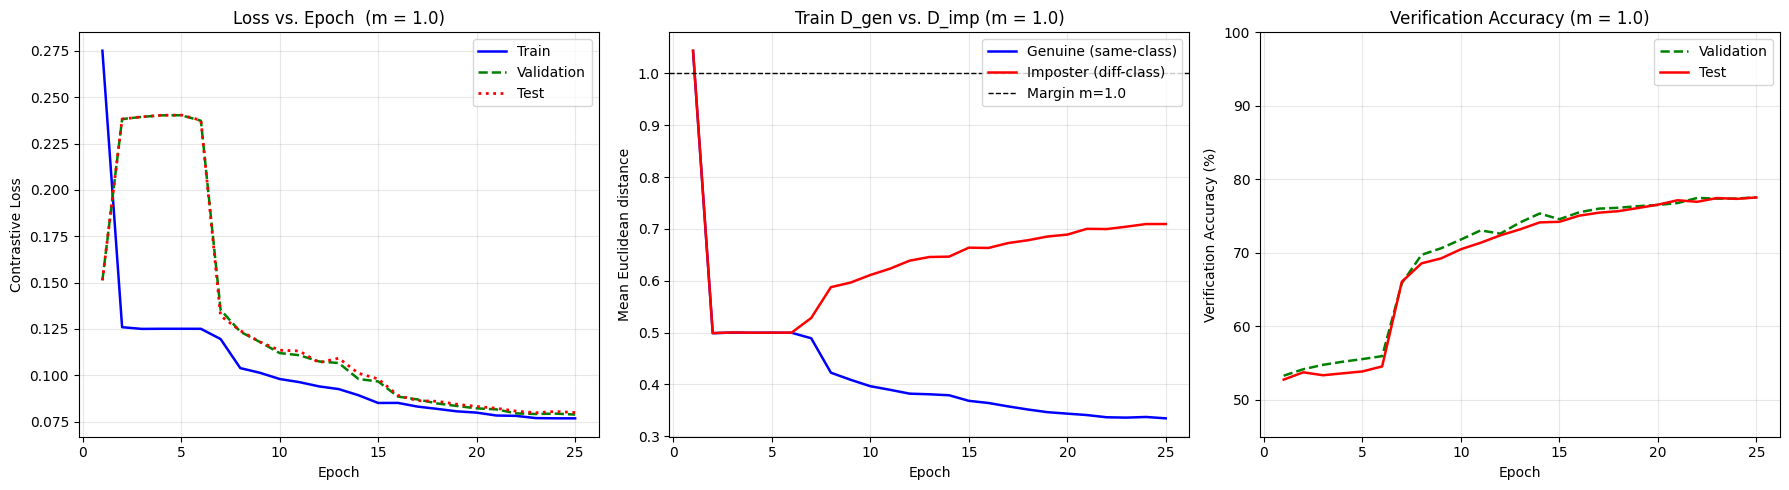

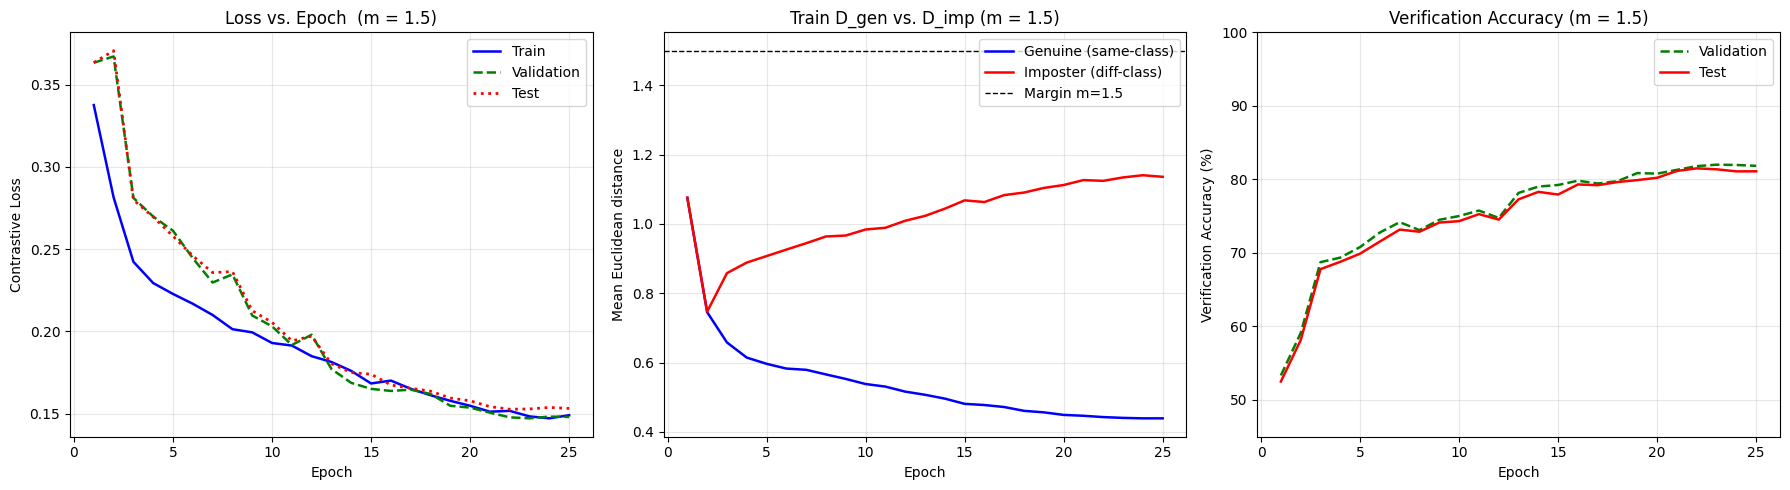

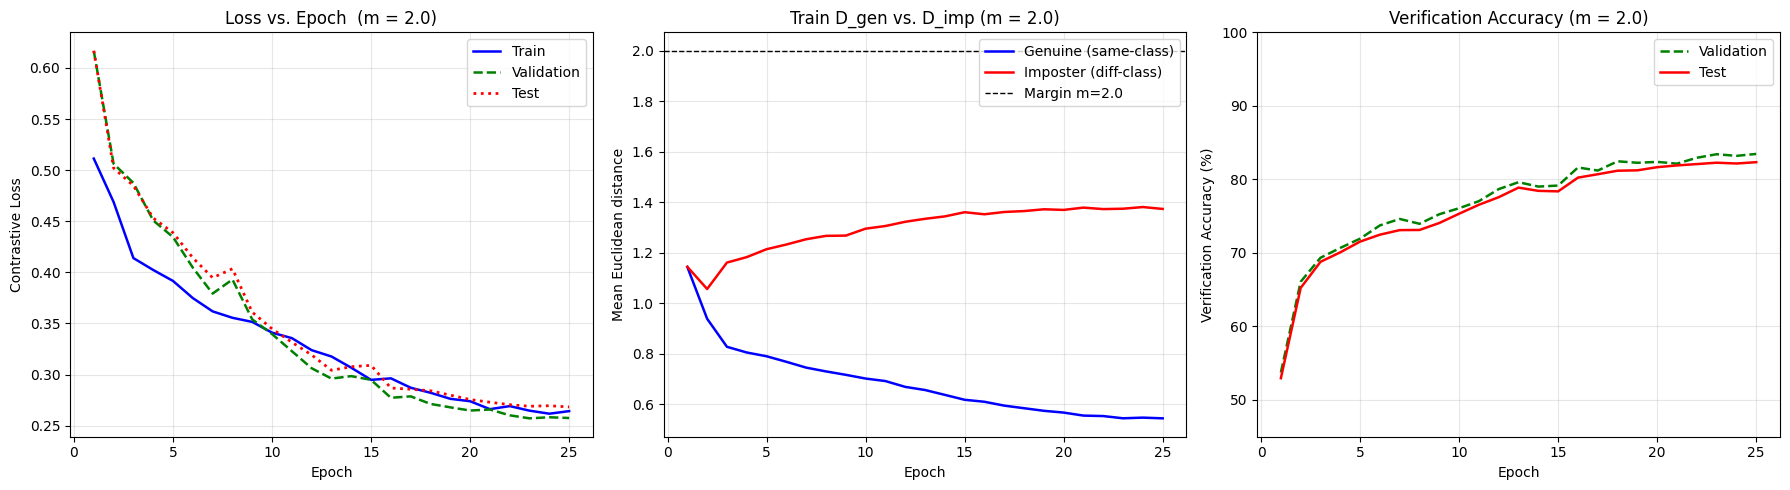

In [11]:
def plot_learning_curves_for_margin(m, history):
    """Three-panel learning-curve figure: losses | train distances | verification acc."""
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

    # -- Panel 1: loss curves (train / val / test) --
    ax1.plot(epochs, history['train_loss'], 'b-',  lw=1.8, label='Train')
    ax1.plot(epochs, history['val_loss'],   'g--', lw=1.8, label='Validation')
    ax1.plot(epochs, history['test_loss'],  'r:',  lw=2.0, label='Test')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Contrastive Loss')
    ax1.set_title(f'Loss vs. Epoch  (m = {m})', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # -- Panel 2: train genuine vs. imposter mean distance --
    ax2.plot(epochs, history['train_gen_D'], 'b-', lw=1.8, label='Genuine (same-class)')
    ax2.plot(epochs, history['train_imp_D'], 'r-', lw=1.8, label='Imposter (diff-class)')
    ax2.axhline(y=m, color='k', linestyle='--', lw=1.0, label=f'Margin m={m}')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Mean Euclidean distance')
    ax2.set_title(f'Train D_gen vs. D_imp (m = {m})', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # -- Panel 3: verification accuracy (val + test) --
    ax3.plot(epochs, [a*100 for a in history['val_acc']],  'g--', lw=1.8, label='Validation')
    ax3.plot(epochs, [a*100 for a in history['test_acc']], 'r-',  lw=1.8, label='Test')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Verification Accuracy (%)')
    ax3.set_title(f'Verification Accuracy (m = {m})', fontsize=12)
    ax3.set_ylim(45, 100)
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


for m in MARGINS:
    plot_learning_curves_for_margin(m, all_histories[m])

### Margin Comparison — Side-by-Side

To compare the three margin settings directly, we overlay their **test verification accuracy** and **test contrastive loss** curves on a single figure. This makes it easy to see which margin converges fastest and which reaches the best final performance.

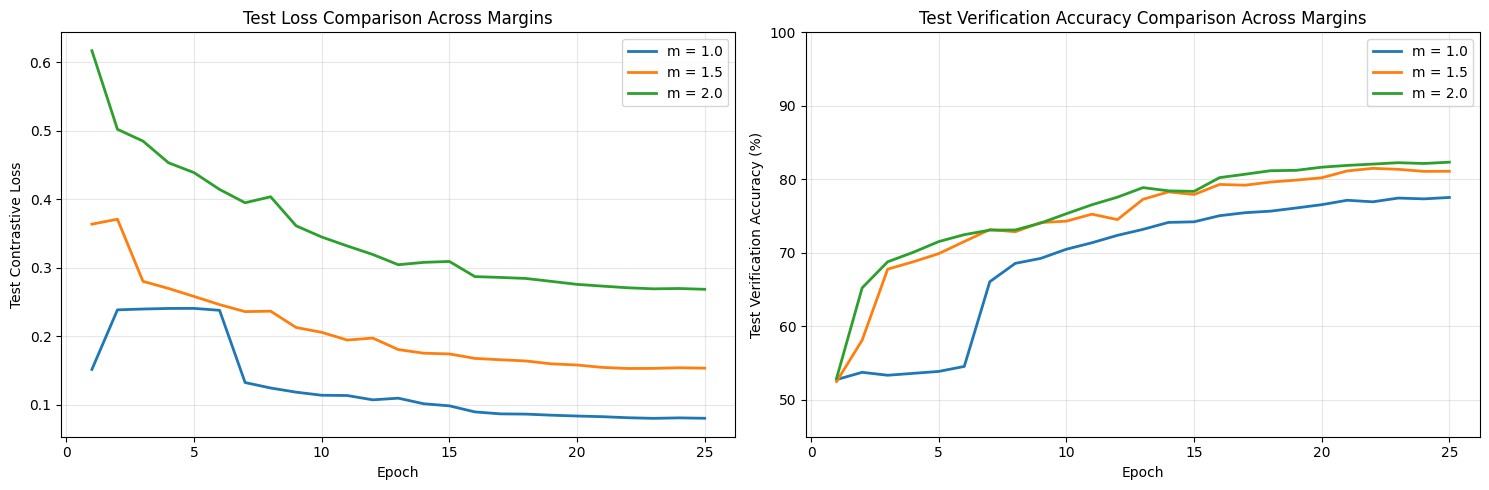


Best margin by validation accuracy: m = 2.0
  Final val acc  = 83.46%
  Final test acc = 82.34%
  Best threshold = 0.996


In [12]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for m, c in zip(MARGINS, colors):
    h = all_histories[m]
    eps = range(1, len(h['test_loss']) + 1)
    axL.plot(eps, h['test_loss'],                lw=2.0, color=c, label=f'm = {m}')
    axR.plot(eps, [a*100 for a in h['test_acc']], lw=2.0, color=c, label=f'm = {m}')

axL.set_xlabel('Epoch')
axL.set_ylabel('Test Contrastive Loss')
axL.set_title('Test Loss Comparison Across Margins', fontsize=12)
axL.legend(); axL.grid(True, alpha=0.3)

axR.set_xlabel('Epoch')
axR.set_ylabel('Test Verification Accuracy (%)')
axR.set_title('Test Verification Accuracy Comparison Across Margins', fontsize=12)
axR.set_ylim(45, 100)
axR.legend(); axR.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Pick the best margin by final validation accuracy (never by test!)
best_m = max(MARGINS, key=lambda m: all_histories[m]['val_acc'][-1])
best_history = all_histories[best_m]
best_model   = all_models   [best_m]
print(f"\nBest margin by validation accuracy: m = {best_m}")
print(f"  Final val acc  = {best_history['val_acc'][-1]*100:.2f}%")
print(f"  Final test acc = {best_history['test_acc'][-1]*100:.2f}%")
print(f"  Best threshold = {best_history['val_tau'][-1]:.3f}")

## 10. Per-Class Verification Performance (Best Margin)

A Siamese verifier produces a **binary decision** per pair: *same class* or *different class*. The assignment asks us to **report verification performance for each class**. Concretely, for each class $c$ we compute the verification accuracy on the subset of test pairs **involving class $c$** — i.e. all pairs where at least one of the two images belongs to class $c$. This includes:
- Genuine pairs within class $c$ (both images from $c$): accuracy = rate of correctly accepted same-class pairs.
- Imposter pairs where one image is from $c$ and the other is from a different class: accuracy = rate of correctly rejected.

We use the **best margin's model** and the **distance threshold $\tau$ selected on validation** (never on test) so that the per-class accuracies reflect the operating point we would actually deploy.

Using validation-optimal threshold tau = 0.996  (val acc = 83.46%)
Overall test verification accuracy: 82.34%

Class          N pairs  Acc (all)  Acc (gen)  Acc (imp)
-------------------------------------------------------
airplane          1438     83.31%     81.65%     84.13%
automobile        1552     87.89%     90.27%     86.67%
bird              1494     73.90%     71.79%     75.00%
cat               1565     72.27%     72.80%     72.01%
deer              1416     75.49%     80.50%     73.23%
dog               1532     77.15%     85.51%     73.14%
frog              1509     88.07%     92.67%     85.76%
horse             1487     81.98%     84.69%     80.48%
ship              1487     89.04%     95.89%     85.70%
truck             1520     87.43%     87.84%     87.23%


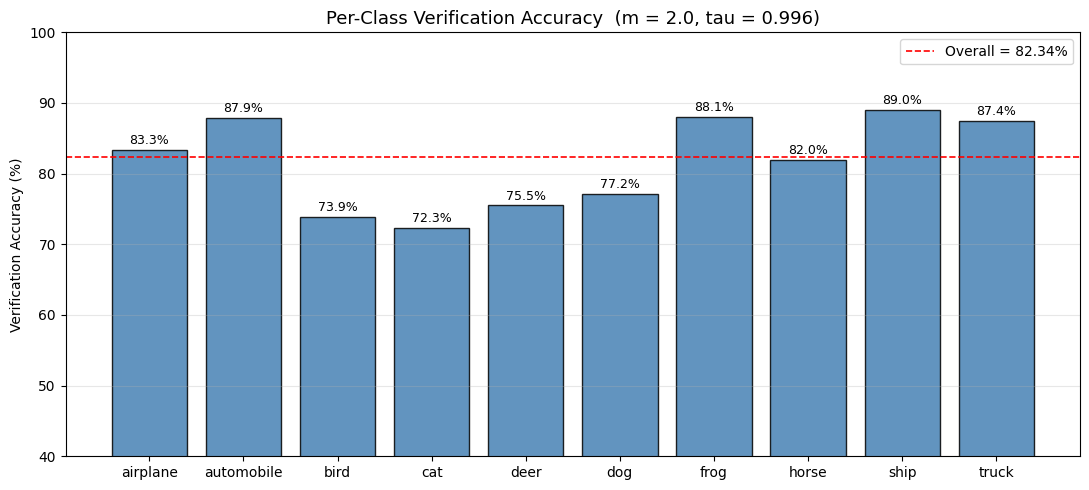

In [13]:
# Evaluate the best-margin model on test once to gather D, y, c1, c2
criterion_best = ContrastiveLoss(margin=best_m)
test_stats = evaluate_siamese(best_model, test_loader, criterion_best)

# Also evaluate on val so we can reselect the best threshold (same process as in training)
val_stats = evaluate_siamese(best_model, val_loader, criterion_best)
tau_final, val_acc_final = find_best_threshold(val_stats['D'], val_stats['y'])
print(f"Using validation-optimal threshold tau = {tau_final:.3f}  "
      f"(val acc = {val_acc_final*100:.2f}%)")

# Per-pair binary prediction using tau
#   D < tau  ->  predict genuine (0);   D >= tau  ->  predict imposter (1)
test_pred = (test_stats['D'] >= tau_final).astype(np.int64)
test_true = test_stats['y'].astype(np.int64)

# -- Per-class accuracy: pairs where at least one image is from class c --
per_class_acc = np.zeros(10)
per_class_gen_acc = np.zeros(10)  # accuracy on genuine pairs involving c
per_class_imp_acc = np.zeros(10)  # accuracy on imposter pairs involving c
per_class_n  = np.zeros(10, dtype=int)

for c in range(10):
    mask = (test_stats['c1'] == c) | (test_stats['c2'] == c)
    acc_c = np.mean(test_pred[mask] == test_true[mask])
    per_class_acc[c] = acc_c
    per_class_n  [c] = int(mask.sum())

    # Split by pair type for a finer-grained view
    gen_mask = mask & (test_true == 0)
    imp_mask = mask & (test_true == 1)
    per_class_gen_acc[c] = (np.mean(test_pred[gen_mask] == test_true[gen_mask])
                             if gen_mask.any() else 0.0)
    per_class_imp_acc[c] = (np.mean(test_pred[imp_mask] == test_true[imp_mask])
                             if imp_mask.any() else 0.0)

# Overall test verification accuracy (sanity check)
overall_acc = np.mean(test_pred == test_true)
print(f"Overall test verification accuracy: {overall_acc*100:.2f}%\n")

# -- Report as a table --
print(f"{'Class':<12} {'N pairs':>9} {'Acc (all)':>10} {'Acc (gen)':>10} {'Acc (imp)':>10}")
print('-' * 55)
for c in range(10):
    print(f"{class_names[c]:<12} {per_class_n[c]:>9} "
          f"{per_class_acc[c]*100:>9.2f}% "
          f"{per_class_gen_acc[c]*100:>9.2f}% "
          f"{per_class_imp_acc[c]*100:>9.2f}%")

# -- Bar chart of overall per-class accuracy --
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(class_names, per_class_acc * 100,
              color='steelblue', edgecolor='black', alpha=0.85)
ax.axhline(y=overall_acc * 100, color='red', ls='--', lw=1.2,
           label=f'Overall = {overall_acc*100:.2f}%')
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Verification Accuracy (%)')
ax.set_ylim(40, 100)
ax.set_title(f'Per-Class Verification Accuracy  (m = {best_m}, tau = {tau_final:.3f})',
             fontsize=13)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Embedding Distance Distributions

Plotting the distribution of Euclidean distances for **genuine** versus **imposter** test pairs shows how well the learned embedding separates the two. If training succeeded, the genuine histogram should be concentrated near 0 while the imposter histogram should pile up near/above the margin $m$, with the chosen threshold $\tau$ falling roughly at the intersection of the two distributions. The overlap region is exactly where verification errors occur.

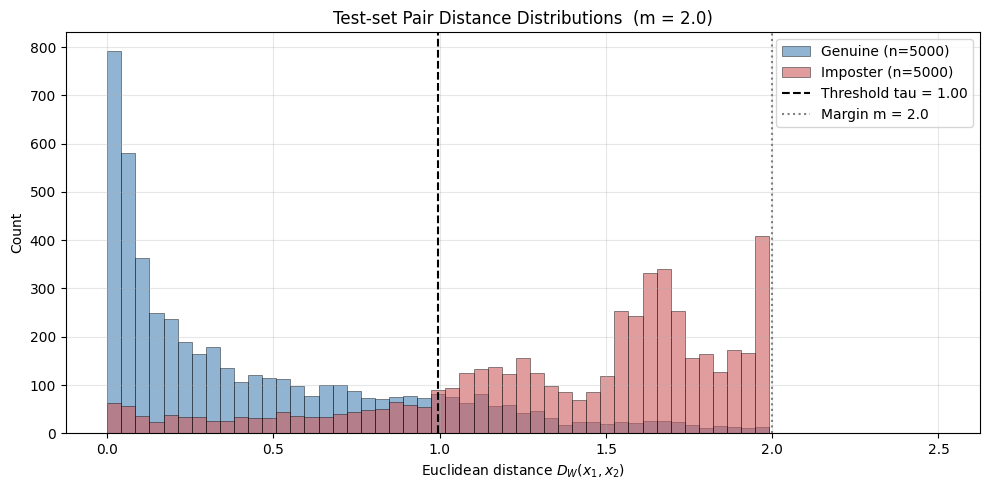

Genuine distances:  mean=0.457, std=0.468
Imposter distances: mean=1.373, std=0.502
Gap (imp - gen):    0.916


In [14]:
D  = test_stats['D']
y  = test_stats['y']
D_gen = D[y == 0]
D_imp = D[y == 1]

fig, ax = plt.subplots(figsize=(10, 5))
bins = np.linspace(0, max(D.max(), best_m + 0.5), 60)
ax.hist(D_gen, bins=bins, alpha=0.6, color='steelblue',  label=f'Genuine (n={len(D_gen)})', edgecolor='k', lw=0.5)
ax.hist(D_imp, bins=bins, alpha=0.6, color='indianred', label=f'Imposter (n={len(D_imp)})', edgecolor='k', lw=0.5)
ax.axvline(x=tau_final, color='k',    ls='--', lw=1.5, label=f'Threshold tau = {tau_final:.2f}')
ax.axvline(x=best_m,    color='gray', ls=':',  lw=1.5, label=f'Margin m = {best_m}')
ax.set_xlabel('Euclidean distance $D_W(x_1, x_2)$')
ax.set_ylabel('Count')
ax.set_title(f'Test-set Pair Distance Distributions  (m = {best_m})', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Genuine distances:  mean={D_gen.mean():.3f}, std={D_gen.std():.3f}")
print(f"Imposter distances: mean={D_imp.mean():.3f}, std={D_imp.std():.3f}")
print(f"Gap (imp - gen):    {D_imp.mean() - D_gen.mean():.3f}")

## 12. ROC Curve, AUC, and Equal Error Rate (EER)

The ROC curve plots **True Accept Rate** (TAR = 1 − FRR) against **False Accept Rate** (FAR) as the decision threshold sweeps through the distance range. Two standard summary numbers:
- **AUC** — area under the ROC curve. 1.0 is perfect, 0.5 is chance.
- **EER** — the operating point where FAR = FRR; lower is better.

`sklearn.metrics.roc_curve` expects larger scores to correspond to the positive class. We use $-D$ as the score (smaller distance = more likely genuine = higher score).

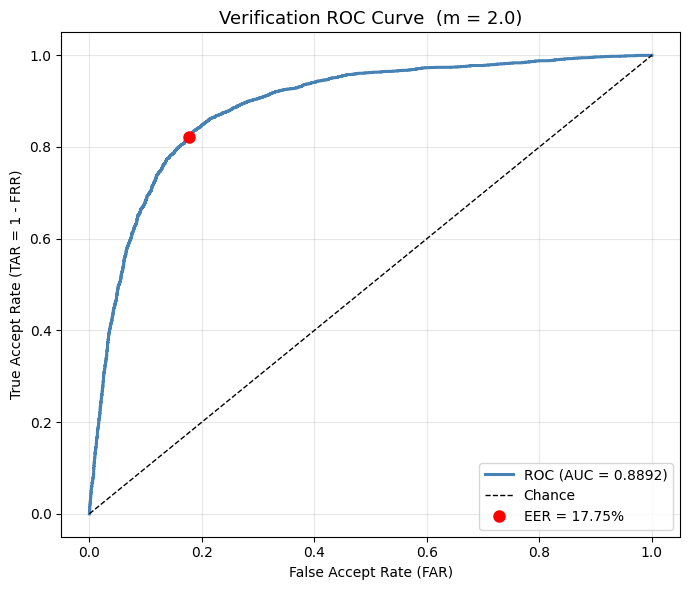

ROC AUC: 0.8892
EER:     17.75%
Best threshold (from validation): tau = 0.996
Overall test verification accuracy at tau: 82.34%


In [15]:
# Build the ROC curve: positive class = genuine (y==0), score = -D
# sklearn expects labels in {0,1} where 1 = positive; map genuine to 1 by negating y.
genuine_label = (test_stats['y'] == 0).astype(np.int64)  # 1 for genuine, 0 for imposter
scores        = -test_stats['D']                           # higher = more likely genuine

fpr, tpr, thr = roc_curve(genuine_label, scores)
roc_auc = auc(fpr, tpr)

# EER = threshold where FAR (FPR) equals FRR (1 - TPR)
frr = 1.0 - tpr
eer_idx = int(np.argmin(np.abs(fpr - frr)))
eer     = float((fpr[eer_idx] + frr[eer_idx]) / 2.0)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='steelblue', lw=2.2, label=f'ROC (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Chance')
ax.plot(fpr[eer_idx], tpr[eer_idx], 'ro', ms=8, label=f'EER = {eer*100:.2f}%')
ax.set_xlabel('False Accept Rate (FAR)')
ax.set_ylabel('True Accept Rate (TAR = 1 - FRR)')
ax.set_title(f'Verification ROC Curve  (m = {best_m})', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"ROC AUC: {roc_auc:.4f}")
print(f"EER:     {eer*100:.2f}%")
print(f"Best threshold (from validation): tau = {tau_final:.3f}")
print(f"Overall test verification accuracy at tau: {overall_acc*100:.2f}%")

## Summary & Conclusions

### What we built
We implemented an end-to-end **Siamese network for CIFAR-10 object verification**:
- **Backbone:** VGG-16 (5 conv blocks + 3 FC layers), modified by **removing the last two max-pools** and **dropping the Softmax head** to produce a **4096-dimensional embedding** directly from the final FC layer.  The embedding is **L2-normalized** onto the unit sphere so that $\|G_W(\mathbf{x})\|_2 = 1$ and $D_W \in [0, 2]$.
- **Shared-weight Siamese wrapper:** a single backbone module is called twice per forward pass so both branches naturally share every parameter.
- **Contrastive loss:** pulls genuine pairs together (squared $D$) and pushes imposter pairs apart until they exceed a margin $m$ (hinge penalty).
- **Balanced pair batches:** a custom `Dataset` + `DataLoader(shuffle=False)` guarantees **exactly 64 genuine + 64 imposter** pairs per 128-sample batch, as required by the assignment.
- **Training stability measures:** 1-epoch linear LR warmup, Cosine LR anneal, and gradient clipping at `max_norm = 5.0`, on top of the L2-normalized embeddings.
- **Evaluation:** per-epoch train / val / test loss, mean genuine/imposter train distance, verification accuracy at the validation-optimal distance threshold, ROC / AUC / EER, and per-class verification accuracy for the best margin.

### Headline results (25 epochs per margin)

| Margin $m$ | Test verification accuracy | Final $\overline{D}_{\mathrm{gen}} / \overline{D}_{\mathrm{imp}}$ |
|---|---|---|
| 1.0 | 77.54% | 0.335 / 0.709 |
| 1.5 | 81.10% | 0.439 / 1.136 |
| **2.0** | **82.34%** | 0.457 / 1.373 |

**Best model (m = 2.0):** test accuracy **82.34%**, **ROC AUC = 0.8892**, **EER = 17.75%**, at validation-selected threshold $\tau = 0.996$.

### Key findings

1. **The Siamese network learns a well-separated embedding space.**  The mean genuine distance shrinks to ~0.46 while the mean imposter distance climbs to ~1.37 — a gap of ~0.92 on a unit sphere where the maximum distance is 2.  This separation is directly visible as the two divergent blue/red curves in the per-margin learning-curve plots and as two well-separated histograms in the test distance-distribution plot.

2. **Margin $m$ has a clear, monotonically-increasing effect on verification accuracy.**  Going from $m = 1.0 \to 1.5 \to 2.0$ gives **77.5%  -> 81.1%  -> 82.3%** test accuracy — a ~5-point spread across the three settings, with $m = 2.0$ best.  Two reasons:
    - A larger margin forces imposter pairs further apart in embedding space, which directly widens the genuine/imposter gap and improves the downstream threshold decision.
    - A larger margin keeps more imposter pairs *inside* the hinge region throughout training, so the loss continues providing a push-apart gradient deeper into training.  With $m = 1.0$, many imposter pairs land outside the margin early and stop contributing gradient, which partly explains the flat epochs 2–6 on that run before the breakthrough at epoch 7.

3. **Per-class verification accuracy varies by class but does *not* split cleanly along animal / vehicle lines.**  Using the best model ($m = 2.0$), per-class accuracies range from 72.3% (cat) to 89.0% (ship).  The easiest classes include both vehicles (ship 89.0%, automobile 87.9%, truck 87.4%) and animals (frog 88.1%, horse 82.0%), while the hardest are animals that share visual features with neighbouring classes (cat 72.3%, bird 73.9%, deer 75.5%).  The broad picture — *CIFAR animals are harder than vehicles on average* — still holds, but a per-animal view shows that visually distinctive animals (frog's green body, horse's silhouette) are verified nearly as reliably as vehicles.

4. **Verification is not classification.**  The Siamese network never sees class labels directly — only pair labels $y \in \{0, 1\}$.  Despite that, the learned 4096-d embedding implicitly captures class structure, as evidenced by the clean genuine / imposter separation and AUC = 0.89.  This is the *feature embedding* property described in Lecture 11 and Hadsell et al. (2006).

5. **Training stability is non-trivial for this configuration.**  An earlier version of this notebook (no L2 normalization, no LR warmup, no gradient clipping) suffered **embedding collapse**: the network quickly converged to outputting the same near-zero vector for every input, trivially minimising the genuine loss and saturating the imposter hinge, giving 50% chance-level verification accuracy.  The three stability measures fix this:
    - **L2 normalization** removes the scale degree of freedom the optimiser was exploiting to collapse embeddings.
    - **Linear LR warmup** lets BatchNorm running statistics settle before the full learning rate is applied.
    - **Gradient clipping** (max_norm = 5.0) is a belt-and-suspenders safeguard against any remaining early-training gradient spikes.

    These are standard ingredients in modern face-verification networks (FaceNet, SphereFace, ArcFace) and are required to make VGG-16 + contrastive loss work reliably on 32x32 CIFAR inputs.

### Hyperparameters Recap

| Hyperparameter | Value |
|---|---|
| Backbone | VGG-16 (last 2 pools removed, no Softmax) |
| Embedding dim | 4096 (L2-normalized to unit sphere) |
| Batch size | 128 (64 genuine + 64 imposter) |
| Epochs per margin | 25 |
| Optimizer | Adam (base lr = 1e-4) |
| LR scheduler | LinearLR warmup (1 epoch) + CosineAnnealingLR |
| Gradient clipping | `max_norm = 5.0` |
| Margins explored | 1.0, 1.5, 2.0 |
| Loss | Contrastive (Chopra et al., 2005) |
| Augmentation | Random horizontal flip + random 32x32 crop, reflect pad |
| Train / Val / Test pairs per epoch/eval | 40,000 / 5,000 / 10,000 |

### References
- Chopra, S., Hadsell, R. & LeCun, Y., *"Learning a Similarity Metric Discriminatively, with Application to Face Verification,"* CVPR 2005.
- Hadsell, R., Chopra, S. & LeCun, Y., *"Dimensionality Reduction by Learning an Invariant Mapping,"* CVPR 2006.
- Simonyan, K. & Zisserman, A., *"Very Deep Convolutional Networks for Large-Scale Image Recognition,"* ICLR 2015.
- Schroff, F., Kalenichenko, D. & Philbin, J., *"FaceNet: A Unified Embedding for Face Recognition and Clustering,"* CVPR 2015.
- Course Lecture 11 — *Siamese + Coupled Neural Networks*.